In [24]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

import torch
import torch.nn as nn
import torch.optim as optim

import torch.utils.data as data
from torchvision import datasets, transforms

import matplotlib.pyplot as plt



In [25]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [26]:
image, label = train_dataset[0]

print(image.shape)

print(label)

torch.Size([1, 28, 28])
5


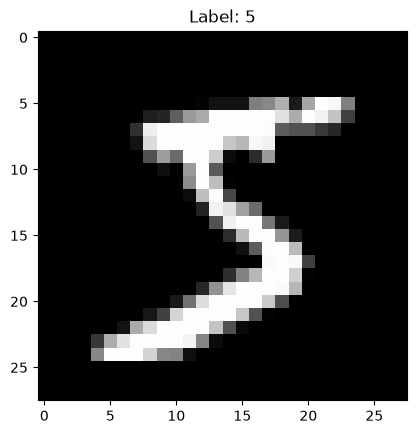

In [27]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.show()

### Batch the data

<div style="border-left: 4px solid #2563eb; background: #eff6ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Why batches?</strong><br>A batch groups several examples into one tensor so PyTorch can process them efficiently. With a batch size of 64, the image shape is <code>[64, 1, 28, 28]</code> and the label shape is <code>[64]</code>. Shuffling the training loader changes the sample order each epoch.</div>

In [28]:
from torch.utils.data import DataLoader

batch_size = 64

# Create data loaders for training and testing
# shuffle=True changes the training order at the start of every epoch.

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)


torch.Size([64, 1, 28, 28])
torch.Size([64])


### Create the MLP

<div style="border-left: 4px solid #7c3aed; background: #f5f3ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Flattening and layers</strong><br>Each 28×28 image is flattened into 784 values before entering the network. The model reduces <code>784 → 128 → 64 → 10</code>. ReLU adds non-linearity, and the final ten values correspond to digit classes 0–9.</div>

![MLP architecture showing MNIST input, flattening, two dense ReLU layers, and ten output logits](mlp_architecture.png)

In [29]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, 10)
        
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input tensor
        return self.network(x)


model = MLP()

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


<div style="border-left: 4px solid #d97706; background: #fffbeb; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Logits</strong><br>The model output contains ten raw scores called logits, not probabilities. <code>argmax()</code> selects the class with the largest score. Use softmax only when probabilities are needed.</div>

In [30]:
images, labels = next(iter(train_loader))

outputs = model(images)

print(outputs.shape)  # Should be [batch_size, 10] for 10 classes

prediction = outputs[0].argmax()

print(prediction)  # Predicted class for the first image in the batch

torch.Size([64, 10])
tensor(2)


<div style="border-left: 4px solid #dc2626; background: #fef2f2; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Training cycle</strong><br>Each batch follows four steps: clear old gradients, run a forward pass, calculate cross-entropy loss, then backpropagate and update the weights. The first standalone loop performs one full training pass before the five-epoch loop, giving six passes in total.</div>

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

for images, labels in train_loader:
    optimizer.zero_grad()  # Clear gradients from the previous step
    outputs = model(images)  # Forward pass
    loss = nn.CrossEntropyLoss()(outputs, labels)  # Compute loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update weights


epoches = 5

for epoch in range(epoches):
    total_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()  # Clear gradients from the previous step
        outputs = model(images)  # Forward pass
        loss = nn.CrossEntropyLoss()(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)


    print(
        f"Epoch {epoch + 1}/{epoches}, "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/5, Loss: 0.0539
Epoch 2/5, Loss: 0.0441
Epoch 3/5, Loss: 0.0353
Epoch 4/5, Loss: 0.0289
Epoch 5/5, Loss: 0.0234


<div style="border-left: 4px solid #059669; background: #ecfdf5; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Evaluation mode</strong><br><code>model.eval()</code> switches the network to evaluation behavior. <code>torch.no_grad()</code> stops gradient tracking, reducing memory use and making inference faster.</div>

In [ ]:
# evaluate the model on the test dataset

model.eval()  # Set the model to evaluation mode

correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation for evaluation
    for images, labels in test_loader:
        outputs = model(images)  # Forward pass
        _, predicted = torch.max(outputs.data, 1)  # Get the index of the max log-probability
        total += labels.size(0)  # Update total number of samples
        correct += (predicted == labels).sum().item()  # Update number of correct predictions
        
accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.77%


<div style="border-left: 4px solid #2563eb; background: #eff6ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — One image still needs a batch dimension</strong><br>A dataset item has shape <code>[1, 28, 28]</code>. The model expects <code>[batch, channel, height, width]</code>, so <code>unsqueeze(0)</code> changes it to <code>[1, 1, 28, 28]</code>.</div>

Prediction: 7
Actual: 7


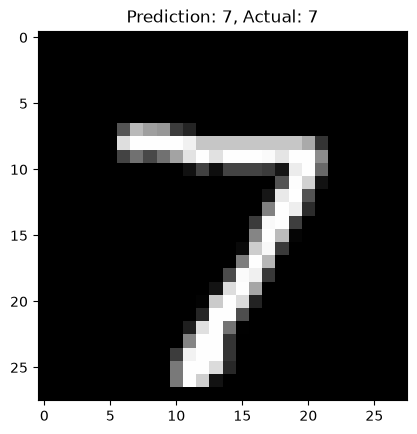

In [40]:
image, label = test_dataset[0]

model.eval()

with torch.no_grad():

    output = model(image.unsqueeze(0))

    prediction = output.argmax(dim=1).item()

print("Prediction:", prediction)
print("Actual:", label)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(
    f"Prediction: {prediction}, Actual: {label}"
)
plt.show()

<div style="border-left: 4px solid #d97706; background: #fffbeb; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Probabilities and saving</strong><br>Softmax converts logits into probabilities that sum to 1. Saving <code>model.state_dict()</code> stores the learned weights without storing the Python class definition.</div>

In [42]:
probabilities = torch.softmax(output, dim=1)

print("Probabilities:", probabilities)

torch.save(
    model.state_dict(),
    "mnist_mlp.pth"
)

Probabilities: tensor([[8.1081e-12, 5.8810e-11, 6.6347e-08, 1.4767e-05, 6.2802e-16, 3.9040e-10,
         2.4594e-18, 9.9999e-01, 1.2230e-09, 2.1463e-08]])


<div style="border-left: 4px solid #7c3aed; background: #f5f3ff; padding: 12px 16px; border-radius: 6px; color: #111827;"><strong>Note — Loading weights</strong><br>Create the same MLP architecture first, load its saved state dictionary, and call <code>eval()</code> before using it for predictions.</div>

In [43]:
model = MLP()

model.load_state_dict(
    torch.load("mnist_mlp.pth")
)

model.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)